# Minimization, constraints, and kinematics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-ipd/tmol/blob/kdidi/sphinx-docs/docs/tutorial/05_minimization_constraints_kinematics.ipynb)

> **Prerequisite.** This notebook builds on the score-function and coordinate concepts in [Scoring and Analysis](03_scoring_and_analysis.ipynb). It introduces `MoveMap` and `FoldForest`, which the FastRelax tutorial reuses.

## Goals

By the end of this tutorial you will be able to:

- minimize a small, checked-in 1ubq slice in Cartesian and kinematic coordinates;
- restrict motion with `CartesianMoveMap` and `MoveMap`;
- construct and inspect a `FoldForest` edge tensor;
- add tested coordinate constraints through `ConstraintSet`/`ConstraintEnergyTerm` utilities; and
- compare weighted scores, raw coordinate displacement, and Kabsch-aligned RMSD for constrained and unconstrained runs.

All examples use fixed seeds and repository fixtures. The notebook intentionally does not fetch structures or parameters from the network. It minimizes existing coordinates but does not repack side chains; rotamer packing is introduced separately in notebooks 04 and 06.

## Setup

In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    from urllib.request import urlopen

    exec(
        urlopen(
            "https://raw.githubusercontent.com/uw-ipd/tmol/"
            "kdidi/sphinx-docs/docs/tutorial/colab_setup.py"
        ).read(),
        globals(),
    )
    setup_colab(["tmol/tests/data/cif/1UBQ.cif"])

In [2]:
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from biotite.structure.io import load_structure

import tmol
from tmol import beta2016_score_function
from tmol.io.pose_stack_from_biotite import pose_stack_from_biotite
from tmol.kinematics.fold_forest import EdgeType, FoldForest
from tmol.kinematics.move_map import CartesianMoveMap, MoveMap
from tmol.optimization.minimizers import run_cart_min, run_kin_min
from tmol.score.constraint.utility import create_mainchain_coordinate_constraints
from tmol.score.score_types import ScoreType

SEED = 20260807
np.random.seed(SEED)
torch.manual_seed(SEED)
warnings.filterwarnings(
    "ignore", message=r"Sparse invariant checks are implicitly disabled.*"
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def show_table(frame):
    """Use a sortable docs table when available, otherwise display pandas."""
    try:
        from itables import show
    except ImportError:
        return display(frame)
    return show(frame)


def score_components(pose_stack, score_function):
    scorer = score_function.render_whole_pose_scoring_module(pose_stack)
    weighted_terms = scorer(
        pose_stack.coords, sum_terms=False, apply_weights=True
    )[:, 0]
    score_types = score_function.all_score_types()
    constraint_index = next(
        index
        for index, score_type in enumerate(score_types)
        if score_type == ScoreType.constraint
    )
    constraint_score = weighted_terms[constraint_index]
    non_constraint_score = weighted_terms.sum() - constraint_score
    return {
        "non_constraint_score_units": float(non_constraint_score.detach().cpu()),
        "constraint_score_units": float(constraint_score.detach().cpu()),
        "reported_total_score_units": float(weighted_terms.sum().detach().cpu()),
    }


def common_atom_mask(reference, mobile, atom_mask=None):
    finite = torch.isfinite(reference.coords).all(dim=-1)
    finite &= torch.isfinite(mobile.coords).all(dim=-1)
    return finite if atom_mask is None else finite & atom_mask


def rms_displacement(reference, mobile, atom_mask=None):
    """Raw RMS displacement in the input frame; no superposition is applied."""
    mask = common_atom_mask(reference, mobile, atom_mask)
    delta = mobile.coords[mask] - reference.coords[mask]
    return float(torch.sqrt(torch.mean(torch.sum(delta * delta, dim=-1))).cpu())


def kabsch_aligned_rmsd(reference, mobile, atom_mask=None):
    """RMSD after least-squares rigid-body superposition of mobile onto reference."""
    mask = common_atom_mask(reference, mobile, atom_mask)
    reference_xyz = reference.coords[mask]
    mobile_xyz = mobile.coords[mask]
    reference_centered = reference_xyz - reference_xyz.mean(dim=0)
    mobile_centered = mobile_xyz - mobile_xyz.mean(dim=0)

    covariance = mobile_centered.T @ reference_centered
    u, _, vh = torch.linalg.svd(covariance)
    handedness = torch.sign(torch.det(u @ vh))
    correction = torch.eye(3, device=mobile_xyz.device, dtype=mobile_xyz.dtype)
    correction[-1, -1] = handedness
    rotation = u @ correction @ vh
    aligned_mobile = mobile_centered @ rotation
    delta = aligned_mobile - reference_centered
    return float(torch.sqrt(torch.mean(torch.sum(delta * delta, dim=-1))).cpu())


def declared_mainchain_atom_mask(pose_stack):
    """Select atoms named in each residue type's TMol polymer declaration."""
    mask = torch.zeros_like(pose_stack.real_atoms)
    atom_names = []
    seen_atom_names = set()
    for pose_index in range(pose_stack.n_poses):
        for block_index in range(pose_stack.max_n_blocks):
            block_type_index = int(
                pose_stack.block_type_ind64[pose_index, block_index].item()
            )
            if block_type_index < 0:
                continue
            block_type = pose_stack.packed_block_types.active_block_types[
                block_type_index
            ]
            polymer = block_type.properties.polymer
            if polymer is None:
                continue
            atom_offset = int(
                pose_stack.block_coord_offset64[pose_index, block_index].item()
            )
            for atom_name in polymer.mainchain_atoms:
                atom_index = atom_offset + block_type.atom_to_idx[atom_name]
                if bool(pose_stack.real_atoms[pose_index, atom_index]):
                    mask[pose_index, atom_index] = True
                    if atom_name not in seen_atom_names:
                        atom_names.append(atom_name)
                        seen_atom_names.add(atom_name)
    return mask, tuple(atom_names)

## Build a small pose and inspect its FoldForest

`FoldForest.reasonable_fold_forest()` derives polymer and jump edges from backbone connectivity. Each edge is `(type, start block, end block, jump index)`. The edge array is batched over poses.

In [3]:
repo_root = Path.cwd()
if not (repo_root / "tmol/tests/data/cif/1UBQ.cif").exists():
    repo_root = Path(tmol.__file__).resolve().parents[1]
cif_path = repo_root / "tmol" / "tests" / "data" / "cif" / "1UBQ.cif"
atom_array = load_structure(str(cif_path), model=1, include_bonds=True)
protein_slice = atom_array[(atom_array.chain_id == "A") & (atom_array.res_id <= 8)]
pose_diagnostics = StringIO()
try:
    with redirect_stdout(pose_diagnostics), redirect_stderr(pose_diagnostics):
        start = pose_stack_from_biotite(protein_slice, device, no_optH=True)
except Exception:
    print(pose_diagnostics.getvalue())
    raise

score_function = beta2016_score_function(device)
score_function.set_weight(ScoreType.constraint, 1.0)
fold_forest = FoldForest.reasonable_fold_forest(start)

edge_names = {int(edge): edge.name for edge in EdgeType}
edge_rows = []
for pose_i in range(start.n_poses):
    for edge_i in range(int(fold_forest.n_edges[pose_i])):
        edge_type, begin, end, jump_index = fold_forest.edges[pose_i, edge_i]
        edge_rows.append(
            {
                "pose": pose_i,
                "edge": edge_i,
                "type": edge_names[int(edge_type)],
                "start": int(begin),
                "end": int(end),
                "jump_index": int(jump_index),
            }
        )

print("input:", cif_path.name)
print("FoldForest edge tensor shape:", fold_forest.edges.shape)
show_table(pd.DataFrame(edge_rows))

input: 1UBQ.cif
FoldForest edge tensor shape: (1, 2, 4)


**Expected observations.** The edge table should contain an explicit `root_jump` whose start is `-1`, followed by polymer edges covering the contiguous 1UBQ slice. A `jump_index` of `-1` is expected for root-jump and polymer edges; only ordinary jumps receive contiguous non-negative jump indices. Missing or overlapping block ranges indicate a malformed forest and should be investigated before minimization.

TMol's `FoldForest` differs from Rosetta's `FoldTree` in one important invariant: every TMol forest has an explicit virtual root at the origin. `reasonable_fold_forest()` follows backbone up/down connections, turns same-chain gaps into jumps, and roots separate chains independently. Its current automatic builder intentionally ignores non-polymer connections such as disulfides.

## Executable constrained and unconstrained workflow

`run_cart_min` accepts `(pose_stack, sfxn, coord_mask=None, optimizer_cls=..., optimizer_kwargs=None, verbose=False)`. `run_kin_min` accepts `(pose_stack, sfxn, ff, mm, optimizer_cls=..., optimizer_kwargs=None, verbose=False, kin_dtype=...)`.

The tensorized `create_mainchain_coordinate_constraints()` utility constructs a `ConstraintSet` with `ConstraintEnergyTerm.harmonic_coordinate` restraints anchored to frozen copies of the starting positions of every atom in TMol's residue-type `mainchain_atoms` declaration. For the standard amino acids in this protein fixture, those atoms are **N, CA, and C**; O is not declared as a TMol main-chain atom and is not constrained by this helper. The harmonic standard deviation is 0.5 Å. The score-function constraint weight controls the contribution, and the code below reports the names, count, sigma, and weight actually used. Weight 1.0 is intentional here and is stronger than the usual Rosetta comparison weight of 0.5; score magnitudes should not be compared without accounting for that difference. This tutorial uses the declared-main-chain utility rather than the narrower `constrain_all_ca()` helper.

### Cartesian and kinematic degrees of freedom

The Cartesian runs move every finite atom coordinate independently. Without coordinate restraints, a single isolated molecule has global translation and rotation directions that do not change its internal score: six rigid-body null modes. Raw displacement can therefore include arbitrary frame drift, whereas Kabsch-aligned RMSD removes the best global translation and rotation before measuring internal change.

The kinematic runs below explicitly fix ordinary jumps and the virtual-root jump, so the chain cannot translate or rotate as a rigid body. `move_all_named_torsions=True` enables both named main-chain and side-chain torsions; with the default ideal kinematics it does not independently optimize bond lengths and angles. By contrast, Cartesian minimization can distort local geometry, but beta2016 actively penalizes it through the nonzero cartbonded score terms `cart_lengths`, `cart_angles`, `cart_torsions`, `cart_impropers`, and `cart_hxltorsions` (each weighted 0.5). Thus Cartesian and kinematic runs are different coordinate models, not interchangeable optimizers over identical degrees of freedom.

In [4]:
cartesian_move_map = CartesianMoveMap(
    coord_mask=torch.isfinite(start.coords).all(dim=-1)
)
kinematic_move_map = MoveMap.from_pose_stack(start)
kinematic_move_map.move_all_named_torsions = True  # named MC and SC torsions
kinematic_move_map.move_all_jumps = False
kinematic_move_map.move_all_root_jumps = False

mainchain_mask, restrained_atom_names = declared_mainchain_atom_mask(start)
constraint_diagnostics = StringIO()
try:
    with redirect_stdout(constraint_diagnostics), redirect_stderr(constraint_diagnostics):
        constrained_start = create_mainchain_coordinate_constraints(start.clone())
except Exception:
    print(constraint_diagnostics.getvalue())
    raise

CONSTRAINT_SIGMA_A = 0.5
constraint_weight = float(score_function.get_weight(ScoreType.constraint))
print("coordinate-restraint atom names:", ", ".join(restrained_atom_names))
print("coordinate-restraint count:", int(mainchain_mask.sum().item()))
print(f"coordinate-restraint sigma: {CONSTRAINT_SIGMA_A:.1f} Å")
print(f"coordinate-restraint score weight: {constraint_weight:.1f}")
print("O is not TMol-declared main chain here and is not constrained.")
print("Weight 1.0 is intentional; Rosetta comparisons commonly use 0.5.")

# Strictly a short smoke-test budget for tutorial/CI runtime. Finite output and
# a lower objective after ten iterations do not demonstrate convergence.
TUTORIAL_MAX_ITER = 10
optimizer_kwargs = {"max_iter": TUTORIAL_MAX_ITER}
print(f"smoke-test optimizer max_iter: {TUTORIAL_MAX_ITER} (convergence not assessed)")

# Every branch starts from the same coordinates, score function, and iteration
# budget. Within each coordinate model, only the presence of restraints changes.
cart_unconstrained = run_cart_min(
    start.clone(),
    score_function,
    coord_mask=cartesian_move_map.coord_mask,
    optimizer_kwargs=optimizer_kwargs,
)
cart_constrained = run_cart_min(
    constrained_start.clone(),
    score_function,
    coord_mask=cartesian_move_map.coord_mask,
    optimizer_kwargs=optimizer_kwargs,
)
kin_unconstrained = run_kin_min(
    start.clone(),
    score_function,
    fold_forest,
    kinematic_move_map,
    optimizer_kwargs=optimizer_kwargs,
)
kin_constrained = run_kin_min(
    constrained_start.clone(),
    score_function,
    fold_forest,
    kinematic_move_map,
    optimizer_kwargs=optimizer_kwargs,
)

coordinate-restraint atom names: N, CA, C
coordinate-restraint count: 24
coordinate-restraint sigma: 0.5 Å
coordinate-restraint score weight: 1.0
O is not TMol-declared main chain here and is not constrained.
Weight 1.0 is intentional; Rosetta comparisons commonly use 0.5.
smoke-test optimizer max_iter: 10 (convergence not assessed)


/tmp/ipykernel_2958/1320857527.py:70: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(torch.sqrt(torch.mean(torch.sum(delta * delta, dim=-1))).cpu())


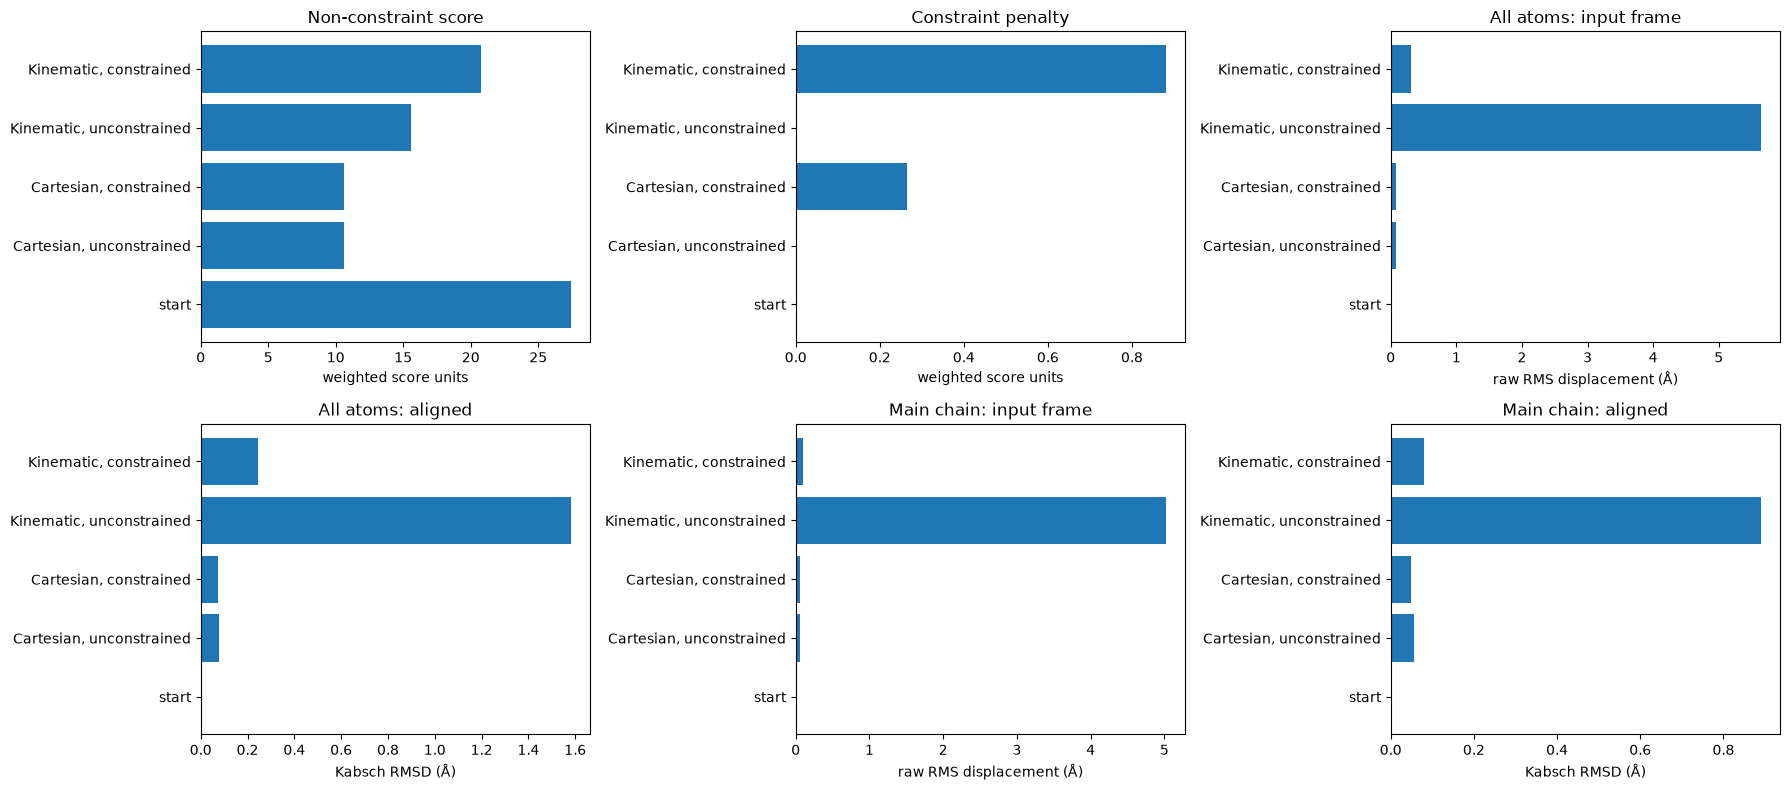

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [5]:
variants = {
    "Cartesian, unconstrained": cart_unconstrained,
    "Cartesian, constrained": cart_constrained,
    "Kinematic, unconstrained": kin_unconstrained,
    "Kinematic, constrained": kin_constrained,
}
mainchain_mask, _ = declared_mainchain_atom_mask(start)
start_components = score_components(start, score_function)
rows = [
    {
        "variant": "start",
        **start_components,
        "non_constraint_score_change_units": 0.0,
        "constraint_score_change_units": 0.0,
        "objective_change_units": 0.0,
        "all_atom_raw_RMS_displacement_A": 0.0,
        "all_atom_Kabsch_RMSD_A": 0.0,
        "mainchain_raw_RMS_displacement_A": 0.0,
        "mainchain_Kabsch_RMSD_A": 0.0,
        "finite_smoke_test_output": True,
        "convergence_status": "not assessed",
    }
]
for name, pose_stack in variants.items():
    components = score_components(pose_stack, score_function)
    all_atom_raw = rms_displacement(start, pose_stack)
    all_atom_aligned = kabsch_aligned_rmsd(start, pose_stack)
    mainchain_raw = rms_displacement(start, pose_stack, mainchain_mask)
    mainchain_aligned = kabsch_aligned_rmsd(start, pose_stack, mainchain_mask)
    numeric_outputs = (
        *components.values(),
        all_atom_raw,
        all_atom_aligned,
        mainchain_raw,
        mainchain_aligned,
    )
    rows.append(
        {
            "variant": name,
            **components,
            "non_constraint_score_change_units": (
                components["non_constraint_score_units"]
                - start_components["non_constraint_score_units"]
            ),
            "constraint_score_change_units": (
                components["constraint_score_units"]
                - start_components["constraint_score_units"]
            ),
            "objective_change_units": (
                components["reported_total_score_units"]
                - start_components["reported_total_score_units"]
            ),
            "all_atom_raw_RMS_displacement_A": all_atom_raw,
            "all_atom_Kabsch_RMSD_A": all_atom_aligned,
            "mainchain_raw_RMS_displacement_A": mainchain_raw,
            "mainchain_Kabsch_RMSD_A": mainchain_aligned,
            "finite_smoke_test_output": bool(np.isfinite(numeric_outputs).all()),
            "convergence_status": "not assessed (10-iteration smoke test)",
        }
    )
comparison_frame = pd.DataFrame(rows)
show_table(comparison_frame)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.ravel()
axes[0].barh(
    comparison_frame["variant"], comparison_frame["non_constraint_score_units"]
)
axes[0].set(xlabel="weighted score units", title="Non-constraint score")
axes[1].barh(
    comparison_frame["variant"], comparison_frame["constraint_score_units"]
)
axes[1].set(xlabel="weighted score units", title="Constraint penalty")
axes[2].barh(
    comparison_frame["variant"],
    comparison_frame["all_atom_raw_RMS_displacement_A"],
)
axes[2].set(xlabel="raw RMS displacement (Å)", title="All atoms: input frame")
axes[3].barh(
    comparison_frame["variant"], comparison_frame["all_atom_Kabsch_RMSD_A"]
)
axes[3].set(xlabel="Kabsch RMSD (Å)", title="All atoms: aligned")
axes[4].barh(
    comparison_frame["variant"],
    comparison_frame["mainchain_raw_RMS_displacement_A"],
)
axes[4].set(xlabel="raw RMS displacement (Å)", title="Main chain: input frame")
axes[5].barh(
    comparison_frame["variant"], comparison_frame["mainchain_Kabsch_RMSD_A"]
)
axes[5].set(xlabel="Kabsch RMSD (Å)", title="Main chain: aligned")
plt.tight_layout()
plt.show()

try:
    restraint_viewer = tmol.view(
        start,
        highlighted=mainchain_mask[start.real_atoms],
        highlight_color="#7b2cbf",
    )
    restraint_viewer.show()
except ImportError:
    print("Install py3Dmol to inspect the restrained main-chain atoms.")

viewer_structures = {"before": start, **variants}
viewer_notes = {"before": "Starting 1UBQ slice"}
for row in rows[1:]:
    viewer_notes[row["variant"]] = (
        f"objective change {row['objective_change_units']:+.3f} score units; "
        f"non-constraint {row['non_constraint_score_units']:.3f}; "
        f"constraint {row['constraint_score_units']:.3f}; "
        f"main-chain raw/aligned "
        f"{row['mainchain_raw_RMS_displacement_A']:.3f}/"
        f"{row['mainchain_Kabsch_RMSD_A']:.3f} Å; convergence not assessed"
    )
display(tmol.switchable_view(viewer_structures, notes=viewer_notes))

**Expected observations.** Every minimized structure should have finite weighted scores, score/objective changes, raw displacements, and aligned RMSDs. Finite output—or even a lower objective—after `max_iter=10` is only a smoke-test result and must not be described as convergence. Establish convergence separately with a suitable iteration budget, stopping diagnostics, and repeatability checks. All-atom metrics include side-chain motion produced by minimization; no packing occurs in this notebook. Main-chain metrics use exactly the restrained TMol-declared N/CA/C atoms, highlighted in purple; O is excluded.

Raw RMS displacement compares coordinates in the original laboratory frame. Kabsch RMSD first removes the best global translation and rotation. A large raw-versus-aligned gap in the unconstrained Cartesian result is evidence of rigid-body drift along its null modes, not the same thing as internal deformation. The kinematic root jump is fixed, so that branch has no equivalent whole-chain drift. Coordinate restraints should generally reduce main-chain motion relative to the matching unconstrained run. Those within-parameterization pairs are controlled comparisons; Cartesian and kinematic endpoints need not agree because their active degrees of freedom differ. The score columns are weighted TMol score units, not physical kcal/mol.

## Rosetta comparison

Rosetta's `MinMover` and Cartesian minimization use a `MoveMap` to select internal or Cartesian degrees of freedom. TMol separates these concepts into `MoveMap` for named torsion/jump DOFs and `CartesianMoveMap` for a per-atom coordinate mask. TMol's tensor representation applies those selections across a `PoseStack` batch. Rosetta Cartesian workflows commonly select a Cartesian-ready score function; TMol beta2016 already gives nonzero weights to its five `cart_*` bonded terms.

Rosetta `FoldTree` can choose a physical residue as the root and represents chemical and jump connectivity within one tree. TMol `FoldForest` is batched and always has a virtual root at the origin. The automatic TMol builder currently follows polymer connectivity and ignores disulfides; construct and validate custom edges when that limitation matters.

Rosetta accepts rich text constraint files and ambiguous/multi constraints. TMol currently has no Rosetta constraint-file parser and no ambiguous-constraint layer. Harmonic distance/coordinate, bounded-distance, and circular-harmonic torsion constraints can be assembled directly through `ConstraintSet` and `ConstraintEnergyTerm`; TMol currently has no dedicated three-atom angle-constraint function.

`ConstraintEnergyTerm.circularharmonic` now wraps angle differences by 2π to the nearest equivalent angle. Regression tests cover periodic score/derivative equivalence under ±2π shifts and equivalent behavior at the −π/+π representation boundary. Thus torsions represented on opposite sides of that branch are compared periodically rather than receiving the former incorrect branch-cut penalty.

## Exercises

1. Change the Cartesian coordinate mask so only residues 3–5 move, then compare the displacement table.
2. Disable side-chain torsions in the kinematic `MoveMap` and enable only main-chain torsions for selected blocks.
3. Replace the coordinate restraints with a tested `ConstraintEnergyTerm.bounded` distance constraint.
4. Build a two-chain slice and identify each virtual-root edge in the edge tensor.
5. Sweep the harmonic standard deviation and plot restraint energy against RMS displacement.

## References

- [Rosetta minimization tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/minimization/minimization)
- [Rosetta constraints tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/Constraints_Tutorial/Constraints)
- [Rosetta FoldTree tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/fold_tree/fold_tree)
- [Rosetta `FoldTree.hh`](https://github.com/RosettaCommons/rosetta/blob/main/source/src/core/kinematics/FoldTree.hh)
- [Rosetta `ConstraintSet.cc`](https://github.com/RosettaCommons/rosetta/blob/main/source/src/core/scoring/constraints/ConstraintSet.cc)